# Reddit-Labeling – Auswertung der Ergebnisse

Tiefenanalyse des vollständigen Labeling-Laufs: Verteilungen, Konfidenz über
Thread-Tiefe, Themenabdeckung je Thread und Korrelationen zwischen den sieben
Dimensionen.

**Läuft lokal** (matplotlib/pandas). Erwartet zwei Dateien unter `../data/`:
- `labels_conversation_threads_resolved.ndjson` – die Label-Ergebnisse
- `conversation_threads_resolved.ndjson` – die Eingabe (für depth, thread_id, subreddit, topic)

Jede Grafik wird zusätzlich als PNG in `./plots/` gespeichert – falls die
Inline-Anzeige (z. B. in DataSpell) mal nicht greift, hast du die Dateien.

**Inhalt**
1. Laden & Zusammenführen
2. Überblick: Abdeckung & ABSTAIN je Dimension
3. Werteverteilungen
4. Konfidenz – gesamt, je Dimension, über Thread-Tiefe
5. Werte über Thread-Tiefe
6. Themen: Abdeckung gesamt & je Thread
7. Korrelationen zwischen Dimensionen (Matrix + Scatter/Density)
8. Konfidenz vs. Kommentarlänge
9. Aufschlüsselung nach Subreddit


## 0. Setup

In [1]:
import json
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
plt.rcParams["figure.dpi"] = 110

PLOTS = Path("./plots"); PLOTS.mkdir(exist_ok=True)
def save(fig, name):
    fig.savefig(PLOTS / f"{name}.png", bbox_inches="tight", dpi=140)
    print("  gespeichert:", PLOTS / f"{name}.png")

# Dimensionen und ihre Typen
ORDINAL = ["stance_intensity", "civility"]        # 1..6
BINARY  = ["sarcasm"]                              # 0/1
CONT    = ["epistemic_modality", "justification_density",
           "responsiveness", "agreement"]         # kontinuierlich
ALL_DIMS = ORDINAL + BINARY + CONT
RANGES = {
    "stance_intensity": (1, 6), "civility": (1, 6), "sarcasm": (0, 1),
    "epistemic_modality": (0, 1), "justification_density": (0, None),
    "responsiveness": (0, 1), "agreement": (-1, 1),
}

## 1. Laden & Zusammenführen

Wir lesen die Label-Ergebnisse (long: eine Zeile je Kommentar×Task), pivotieren
sie in eine breite Tabelle (eine Zeile je Kommentar, je Dimension eine Spalte
für Wert und Konfidenz) und joinen die Struktur-Infos aus der Eingabedatei.

In [2]:
DATA = Path("../data")
RESULTS_PATH = DATA / "labels_conversation_threads_resolved.ndjson"
INPUT_PATH   = DATA / "conversation_threads_resolved.ndjson"

assert RESULTS_PATH.exists(), f"Nicht gefunden: {RESULTS_PATH.resolve()}"
assert INPUT_PATH.exists(),   f"Nicht gefunden: {INPUT_PATH.resolve()}"
print("Ergebnisse:", RESULTS_PATH.resolve())
print("Eingabe:   ", INPUT_PATH.resolve())

Ergebnisse: /Users/arthur/DataspellProjects/reddit-l/data/labels_conversation_threads_resolved.ndjson
Eingabe:    /Users/arthur/DataspellProjects/reddit-l/data/conversation_threads_resolved.ndjson


In [3]:
# --- Ergebnisse laden (long) ---
scores = defaultdict(dict)      # comment_id -> {task: numeric score/label}
confs  = defaultdict(dict)      # comment_id -> {task: confidence}
abstain = defaultdict(set)      # comment_id -> {tasks die ABSTAIN sind}
errors_by_task = Counter()
ntokens = {}
n_lines = 0

def to_num(v):
    if isinstance(v, bool): return None
    if isinstance(v, (int, float)): return float(v)
    return None

with open(RESULTS_PATH) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        n_lines += 1
        r = json.loads(line)
        cid = r["comment_id"]; task = r.get("task")
        if r.get("n_tokens") is not None:
            ntokens[cid] = r["n_tokens"]
        res = r.get("result", {})
        if not isinstance(res, dict):
            continue
        if "error" in res:
            errors_by_task[task] += 1
            continue
        val = res.get("score", res.get("label"))
        conf = res.get("confidence")
        if val == "ABSTAIN":
            abstain[cid].add(task)
        else:
            num = to_num(val)
            if num is not None:
                scores[cid][task] = num
        if isinstance(conf, (int, float)):
            confs[cid][task] = float(conf)

print(f"Ergebniszeilen gelesen: {n_lines:,}")
print(f"Kommentare mit >=1 Score: {len(scores):,}")
print(f"Fehler je Task: {dict(errors_by_task)}")

Ergebniszeilen gelesen: 842,751
Kommentare mit >=1 Score: 120,389
Fehler je Task: {'agreement': 2425, 'stance_intensity': 4, 'epistemic_modality': 4, 'justification_density': 4, 'responsiveness': 4, 'civility': 4, 'sarcasm': 4}


In [4]:
# --- Breite Tabellen bauen ---
all_cids = set(scores) | set(confs) | set(abstain)
rows = []
for cid in all_cids:
    row = {"comment_id": cid, "n_tokens": ntokens.get(cid)}
    for t in ALL_DIMS:
        row[t] = scores.get(cid, {}).get(t, np.nan)
        row[f"{t}__conf"] = confs.get(cid, {}).get(t, np.nan)
        row[f"{t}__abstain"] = t in abstain.get(cid, set())
    rows.append(row)
dfw = pd.DataFrame(rows)
print("Breite Tabelle:", dfw.shape)
dfw.head(3)

Breite Tabelle: (120389, 23)


,comment_id,n_tokens,stance_intensity,stance_intensity__conf,stance_intensity__abstain,civility,civility__conf,civility__abstain,sarcasm,sarcasm__conf,sarcasm__abstain,epistemic_modality,epistemic_modality__conf,epistemic_modality__abstain,justification_density,justification_density__conf,justification_density__abstain,responsiveness,responsiveness__conf,responsiveness__abstain,agreement,agreement__conf,agreement__abstain
0,lbju8h0,274,1.0,0.95,False,1.0,0.95,False,1.0,0.95,False,0.00,0.9,False,0.5,0.8,False,0.9,0.95,False,-1.0,0.95,False
1,l9gzn58,72,6.0,0.95,False,5.0,0.80,False,0.0,0.95,False,0.55,0.8,False,1.5,0.8,False,0.9,0.95,False,1.0,0.95,False
2,lbn5nuk,36,6.0,0.95,False,5.0,0.80,False,0.0,0.90,False,0.00,0.8,False,0.5,0.8,False,0.9,0.95,False,-0.8,0.90,False


In [5]:
# --- Struktur-Infos aus der Eingabe joinen ---
struct = {}
with open(INPUT_PATH) as f:
    for line in f:
        line = line.strip()
        if not line: continue
        r = json.loads(line)
        struct[r["comment_id"]] = {
            "depth": r.get("depth"),
            "thread_id": r.get("thread_id"),
            "subreddit": r.get("subreddit"),
            "best_topic_index": r.get("best_topic_index"),
            "is_post": bool(r.get("is_post", False)),
        }
ds = pd.DataFrame.from_dict(struct, orient="index")
ds.index.name = "comment_id"
dfw = dfw.merge(ds, left_on="comment_id", right_index=True, how="left")
print("Nach Join:", dfw.shape)
print("Kommentare ohne Struktur-Match:", dfw['depth'].isna().sum())
# Posts (depth==-1) für die inhaltliche Analyse i.d.R. ausklammern
dfc = dfw[dfw["is_post"] != True].copy()
print("Kommentare ohne Posts:", len(dfc))
dfw.head(3)

Nach Join: (120389, 28)
Kommentare ohne Struktur-Match: 0
Kommentare ohne Posts: 119401


,comment_id,n_tokens,stance_intensity,stance_intensity__conf,stance_intensity__abstain,civility,civility__conf,civility__abstain,sarcasm,sarcasm__conf,sarcasm__abstain,epistemic_modality,epistemic_modality__conf,epistemic_modality__abstain,justification_density,justification_density__conf,justification_density__abstain,responsiveness,responsiveness__conf,responsiveness__abstain,agreement,agreement__conf,agreement__abstain,depth,thread_id,subreddit,best_topic_index,is_post
0,lbju8h0,274,1.0,0.95,False,1.0,0.95,False,1.0,0.95,False,0.00,0.9,False,0.5,0.8,False,0.9,0.95,False,-1.0,0.95,False,1,1duqpw7,changemyview,12,False
1,l9gzn58,72,6.0,0.95,False,5.0,0.80,False,0.0,0.95,False,0.55,0.8,False,1.5,0.8,False,0.9,0.95,False,1.0,0.95,False,0,1dk6xxf,AskReddit,15,False
2,lbn5nuk,36,6.0,0.95,False,5.0,0.80,False,0.0,0.90,False,0.00,0.8,False,0.5,0.8,False,0.9,0.95,False,-0.8,0.90,False,3,1dugnwv,worldnews,3,False


## 2. Überblick: Abdeckung & ABSTAIN je Dimension

,Dimension,gelabelt,ABSTAIN,Fehler,Ø Konfidenz
0,stance_intensity,119401,0,4,0.792
1,civility,119401,0,4,0.839
2,sarcasm,119401,0,4,0.800
3,epistemic_modality,119401,0,4,0.699
4,justification_density,119401,0,4,0.705
5,responsiveness,115214,4187,4,0.782
6,agreement,112824,4156,2425,0.739


  gespeichert: plots/02_abdeckung.png


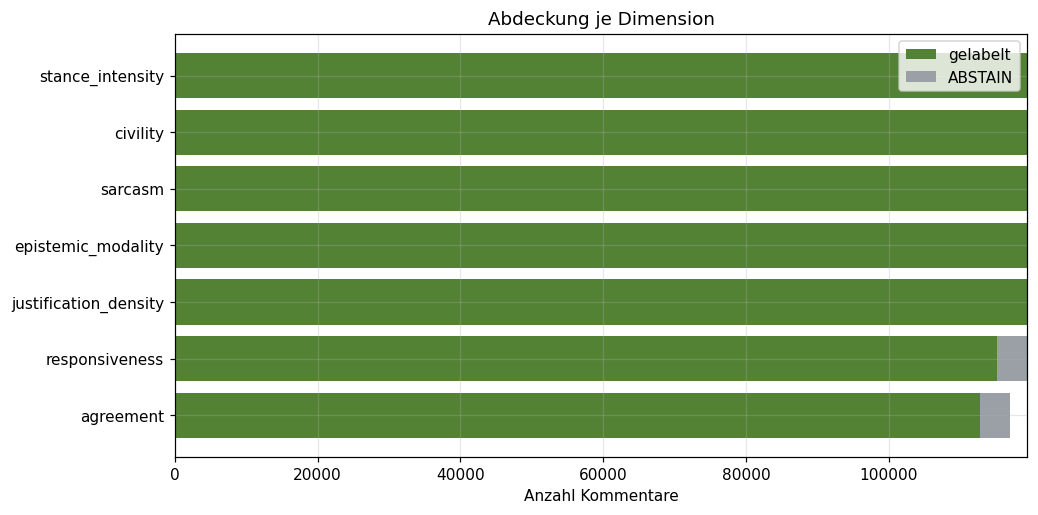

In [6]:
overview = []
for t in ALL_DIMS:
    labeled = dfc[t].notna().sum()
    abst = dfc[f"{t}__abstain"].sum()
    mc = dfc[f"{t}__conf"].mean()
    overview.append({"Dimension": t, "gelabelt": int(labeled),
                     "ABSTAIN": int(abst), "Fehler": int(errors_by_task.get(t,0)),
                     "Ø Konfidenz": round(mc,3)})
ov = pd.DataFrame(overview)
display(ov)

fig, ax = plt.subplots(figsize=(10,5))
y = range(len(ALL_DIMS))
lab = [dfc[t].notna().sum() for t in ALL_DIMS]
ab  = [dfc[f"{t}__abstain"].sum() for t in ALL_DIMS]
ax.barh(y, lab, color="#548235", label="gelabelt")
ax.barh(y, ab, left=lab, color="#9AA0A6", label="ABSTAIN")
ax.set_yticks(list(y)); ax.set_yticklabels(ALL_DIMS); ax.invert_yaxis()
ax.set_xlabel("Anzahl Kommentare"); ax.set_title("Abdeckung je Dimension")
ax.legend()
save(fig, "02_abdeckung"); plt.show()

## 3. Werteverteilungen je Dimension

  gespeichert: plots/03_verteilungen.png


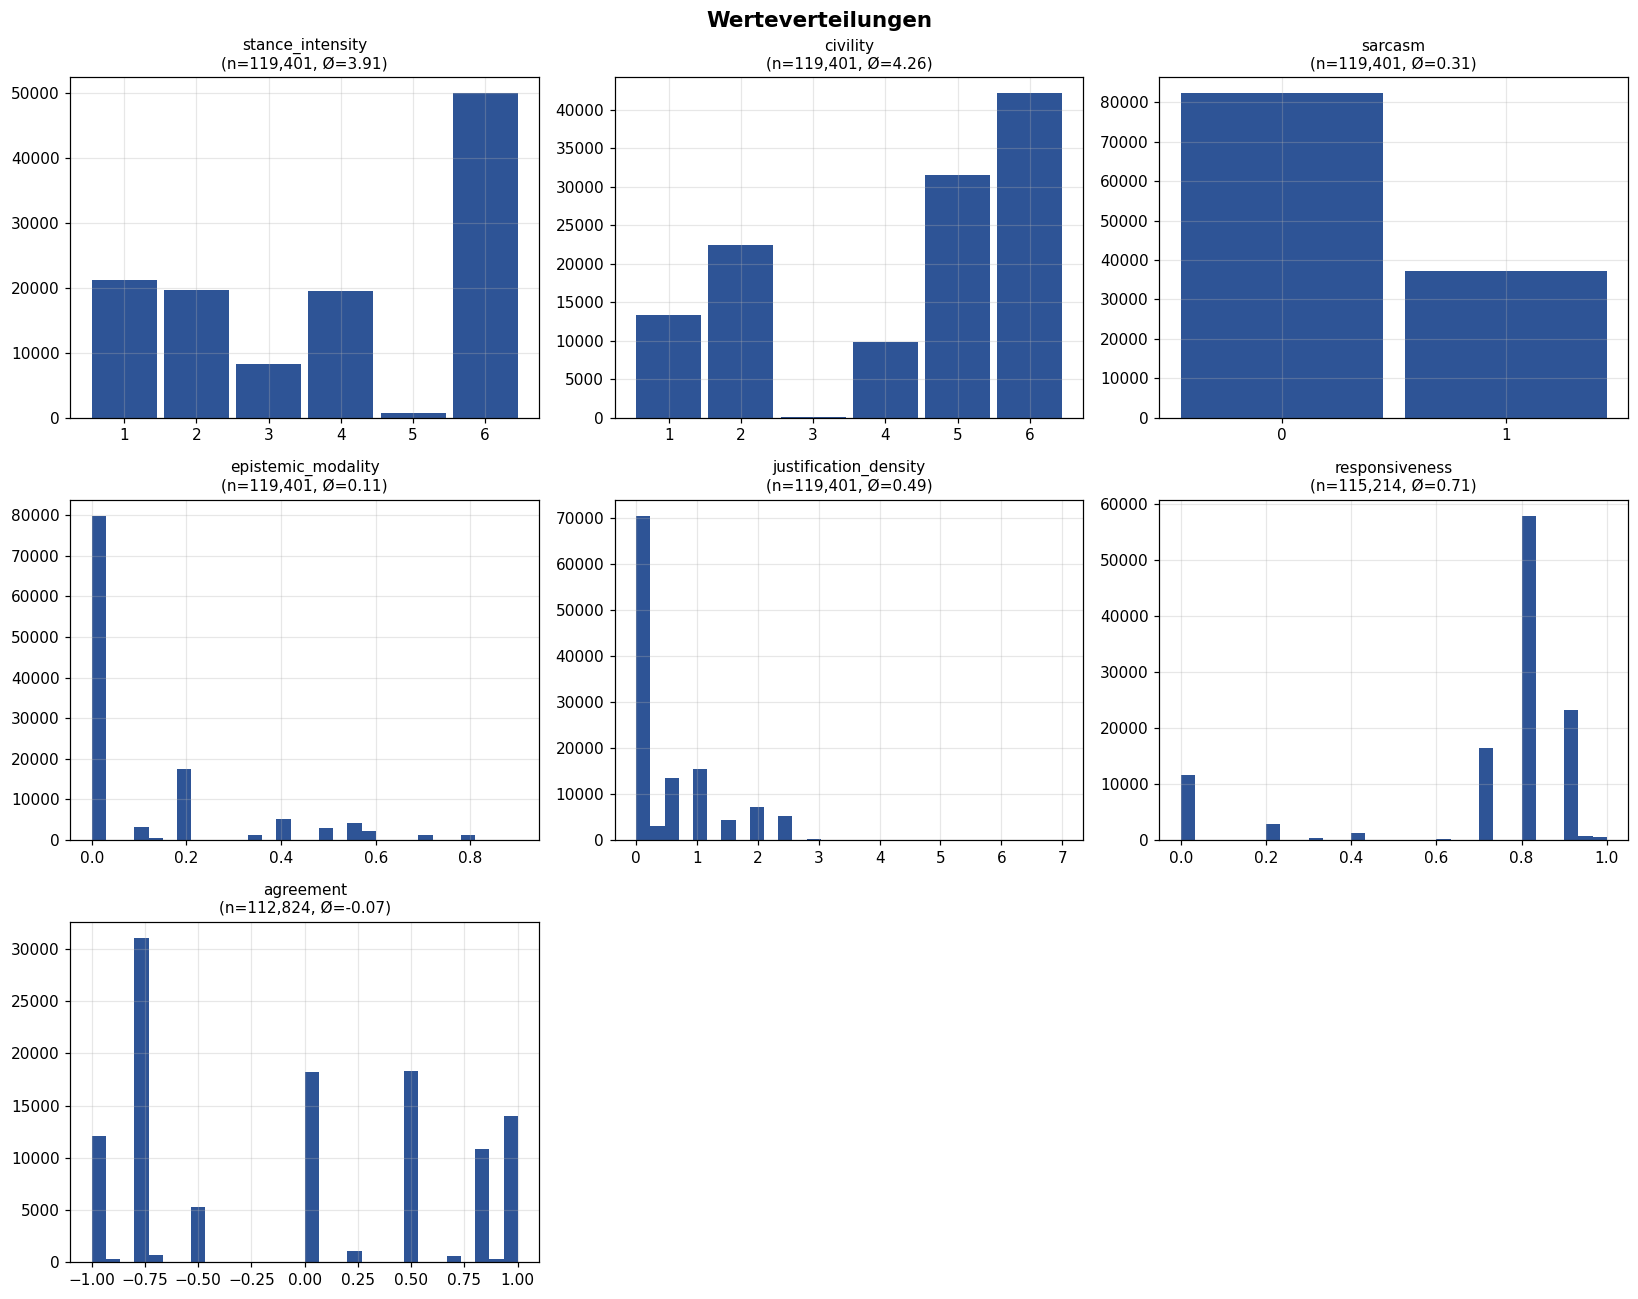

In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, t in enumerate(ALL_DIMS):
    ax = axes[i]
    vals = dfc[t].dropna()
    if t in ORDINAL:
        lo, hi = RANGES[t]
        ax.hist(vals, bins=np.arange(lo-0.5, hi+1.5, 1), color="#2E5496", rwidth=0.9)
    elif t in BINARY:
        ax.hist(vals, bins=[-0.5,0.5,1.5], color="#2E5496", rwidth=0.9)
        ax.set_xticks([0,1])
    else:
        ax.hist(vals, bins=30, color="#2E5496")
    ax.set_title(f"{t}\n(n={len(vals):,}, Ø={vals.mean():.2f})", fontsize=10)
for j in range(len(ALL_DIMS), len(axes)):
    axes[j].axis("off")
fig.suptitle("Werteverteilungen", fontsize=14, fontweight="bold")
plt.tight_layout()
save(fig, "03_verteilungen"); plt.show()

## 4. Konfidenz

Erst die Gesamtverteilung je Dimension, dann der Kernpunkt: **Konfidenz über die
Thread-Tiefe**. Sinkt die Sicherheit des Modells, je tiefer ein Kommentar im
Thread hängt (mehr Kontext nötig)? Oder bleibt sie stabil?

  gespeichert: plots/04a_konfidenz_verteilung.png


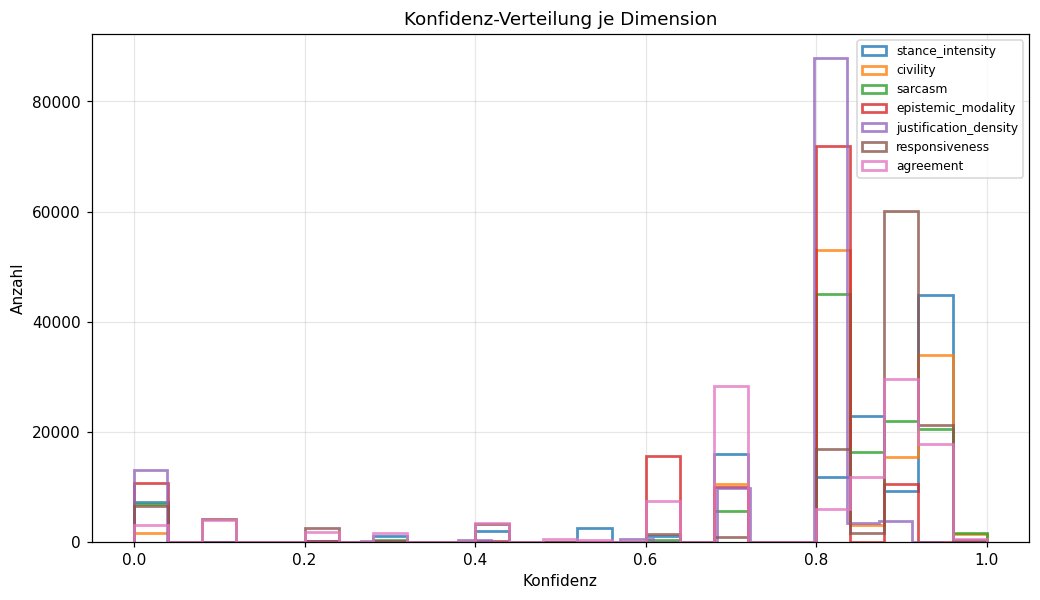

In [8]:
# Konfidenz-Verteilung je Dimension (überlagert)
fig, ax = plt.subplots(figsize=(11,6))
for t in ALL_DIMS:
    c = dfc[f"{t}__conf"].dropna()
    if len(c):
        ax.hist(c, bins=25, histtype="step", linewidth=1.8, label=t, alpha=0.8)
ax.set_xlabel("Konfidenz"); ax.set_ylabel("Anzahl")
ax.set_title("Konfidenz-Verteilung je Dimension")
ax.legend(fontsize=8)
save(fig, "04a_konfidenz_verteilung"); plt.show()

  gespeichert: plots/04b_konfidenz_ueber_tiefe.png


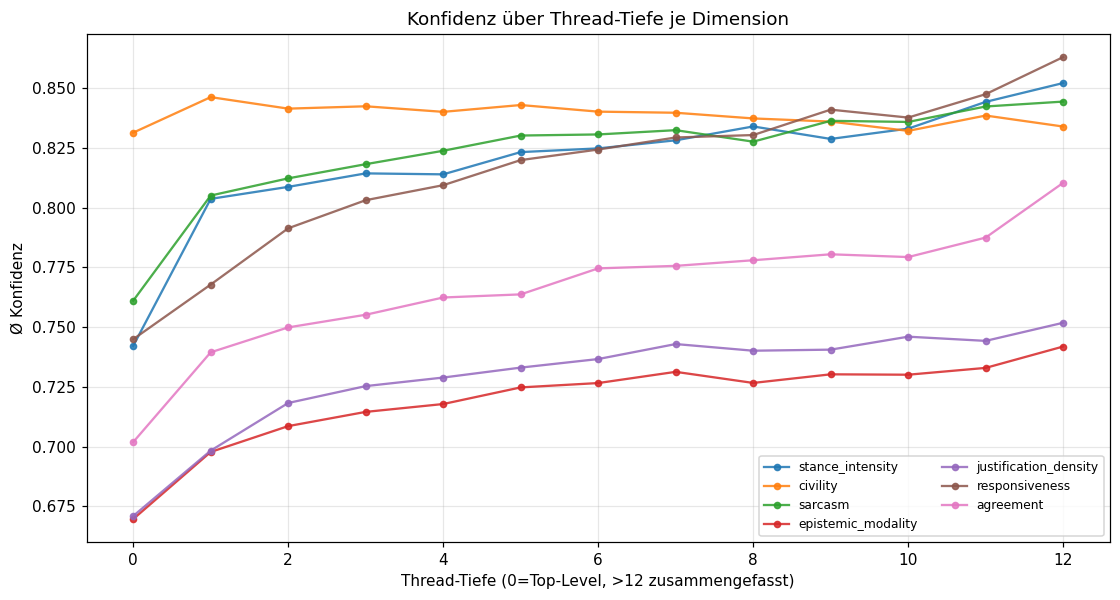

  gespeichert: plots/04c_tiefe_besetzung.png


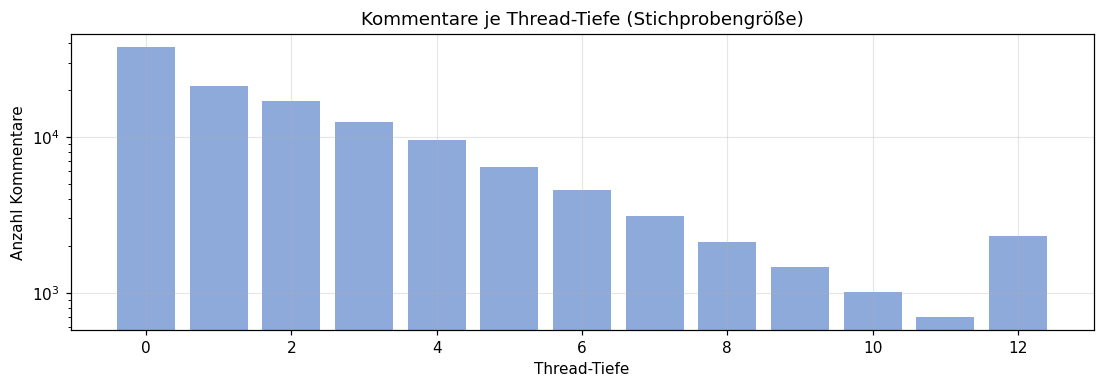

In [9]:
# Konfidenz über Thread-Tiefe
depth_max = 12  # tiefere Ebenen zusammenfassen (dünn besetzt)
d = dfc.copy()
d["depth_cap"] = d["depth"].clip(upper=depth_max)

fig, ax = plt.subplots(figsize=(12,6))
for t in ALL_DIMS:
    g = d.groupby("depth_cap")[f"{t}__conf"].mean()
    ax.plot(g.index, g.values, marker="o", markersize=4, label=t, alpha=0.85)
ax.set_xlabel(f"Thread-Tiefe (0=Top-Level, >{depth_max} zusammengefasst)")
ax.set_ylabel("Ø Konfidenz")
ax.set_title("Konfidenz über Thread-Tiefe je Dimension")
ax.legend(fontsize=8, ncol=2)
save(fig, "04b_konfidenz_ueber_tiefe"); plt.show()

# Wie viele Kommentare je Tiefe? (Kontext für die Aussagekraft oben)
depth_counts = d["depth_cap"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(12,3.5))
ax.bar(depth_counts.index, depth_counts.values, color="#8EAADB")
ax.set_xlabel("Thread-Tiefe"); ax.set_ylabel("Anzahl Kommentare")
ax.set_title("Kommentare je Thread-Tiefe (Stichprobengröße)")
ax.set_yscale("log")
save(fig, "04c_tiefe_besetzung"); plt.show()

## 5. Werteverlauf über Thread-Tiefe

Ändern sich die inhaltlichen Werte mit der Tiefe? Erwartbare Hypothesen: Weiter
unten wird's ggf. unhöflicher (civility sinkt) oder responsiver (direkte
Auseinandersetzung). Hier sichtbar zu machen.

  gespeichert: plots/05_werte_ueber_tiefe.png


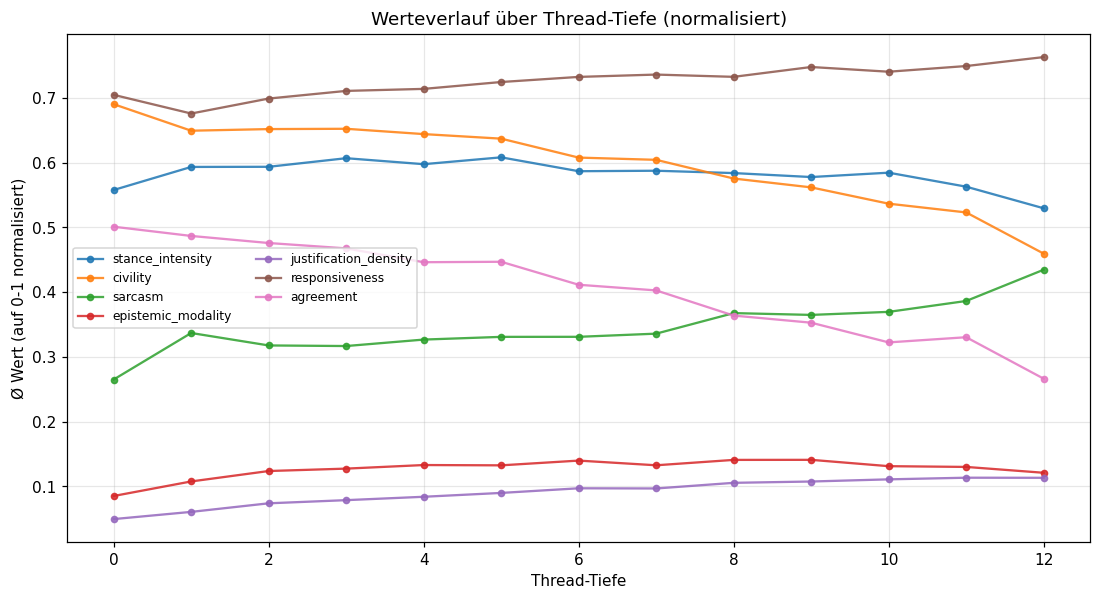

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
for t in ALL_DIMS:
    g = d.groupby("depth_cap")[t].mean()
    # auf 0-1 normalisieren für Vergleichbarkeit im selben Plot
    lo, hi = RANGES[t]
    hi = hi if hi is not None else d[t].max()
    gn = (g - lo) / (hi - lo) if hi != lo else g
    ax.plot(gn.index, gn.values, marker="o", markersize=4, label=t, alpha=0.85)
ax.set_xlabel("Thread-Tiefe"); ax.set_ylabel("Ø Wert (auf 0-1 normalisiert)")
ax.set_title("Werteverlauf über Thread-Tiefe (normalisiert)")
ax.legend(fontsize=8, ncol=2)
save(fig, "05_werte_ueber_tiefe"); plt.show()

## 6. Themen-Abdeckung

`best_topic_index` ist das dominante Thema der Submission. Zwei Blickwinkel:
gesamte Verteilung und – interessanter – wie viele **verschiedene Themen** in
einzelnen Threads vorkommen (bzw. ob ein Thread thematisch homogen ist).

  gespeichert: plots/06a_themen_gesamt.png


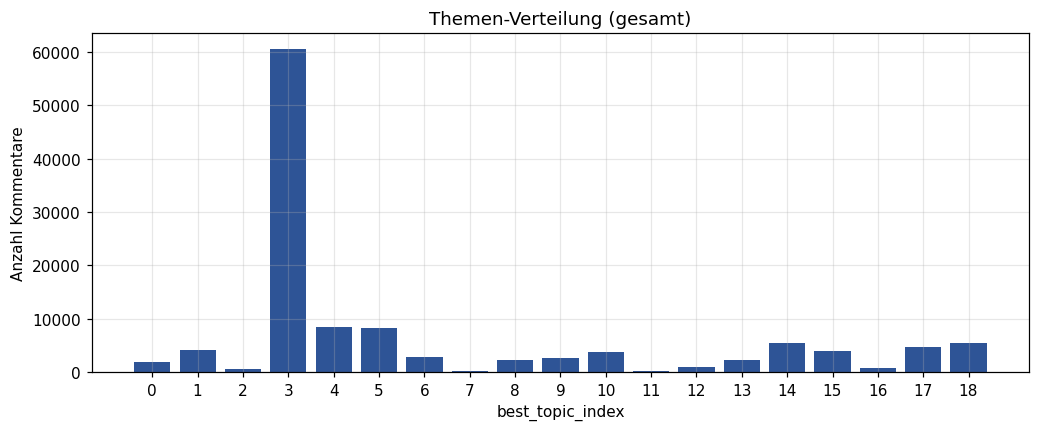

In [11]:
# Gesamtverteilung der Themen
if dfc["best_topic_index"].notna().any():
    tc = dfc["best_topic_index"].value_counts().sort_index()
    fig, ax = plt.subplots(figsize=(11,4))
    ax.bar(tc.index.astype(str), tc.values, color="#2E5496")
    ax.set_xlabel("best_topic_index"); ax.set_ylabel("Anzahl Kommentare")
    ax.set_title("Themen-Verteilung (gesamt)")
    save(fig, "06a_themen_gesamt"); plt.show()
else:
    print("Kein best_topic_index vorhanden.")

Verschiedene Themen pro Thread:
best_topic_index
1    988
Name: count, dtype: int64
  gespeichert: plots/06b_themen_subreddit.png


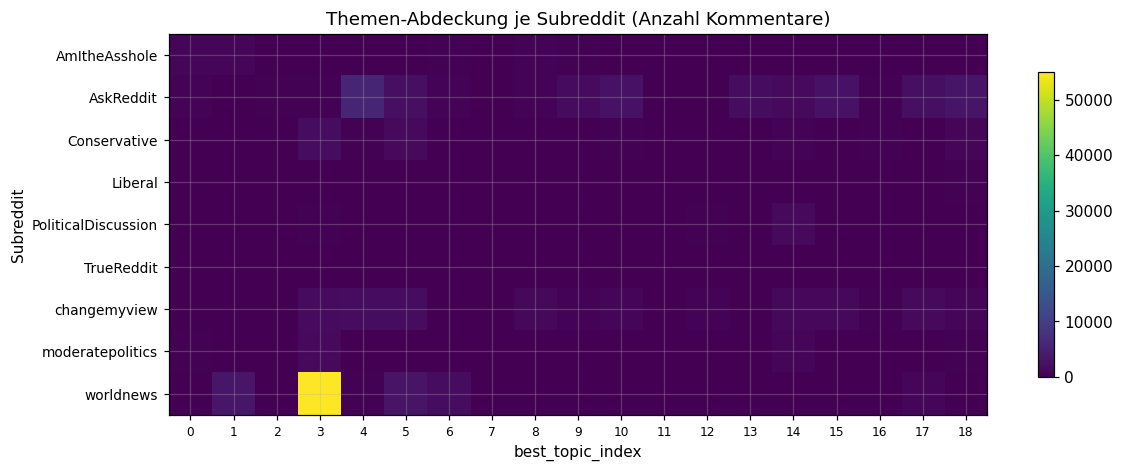

In [12]:
# Themen je Thread: da best_topic_index an der Submission hängt, ist ein Thread
# meist EINEM Thema zugeordnet. Wir prüfen das und zeigen die Themen-Abdeckung
# je Subreddit (Kreuztabelle) als Heatmap.
if dfc["best_topic_index"].notna().any():
    # Themen pro Thread (sollte meist 1 sein)
    per_thread = dfc.groupby("thread_id")["best_topic_index"].nunique()
    print("Verschiedene Themen pro Thread:")
    print(per_thread.value_counts().sort_index())

    # Subreddit x Thema Kreuztabelle
    ct = pd.crosstab(dfc["subreddit"], dfc["best_topic_index"])
    fig, ax = plt.subplots(figsize=(12, max(3, len(ct)*0.5)))
    im = ax.imshow(ct.values, aspect="auto", cmap="viridis")
    ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns, fontsize=8)
    ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, fontsize=9)
    ax.set_xlabel("best_topic_index"); ax.set_ylabel("Subreddit")
    ax.set_title("Themen-Abdeckung je Subreddit (Anzahl Kommentare)")
    fig.colorbar(im, ax=ax, shrink=0.8)
    save(fig, "06b_themen_subreddit"); plt.show()

  gespeichert: plots/06c_thread_themenvielfalt.png


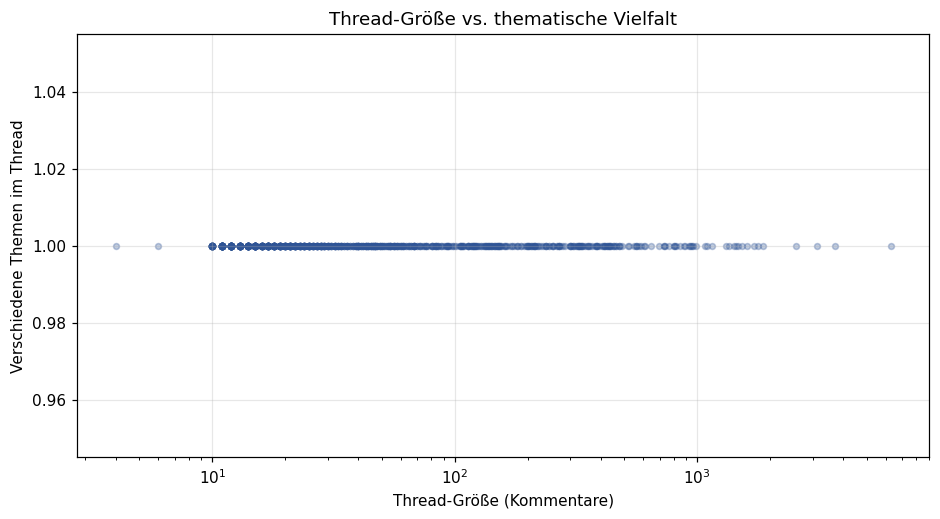

In [13]:
# Threadgröße vs. Themen-Homogenität: gibt es thematisch gemischte Threads?
if dfc["best_topic_index"].notna().any():
    thread_stats = dfc.groupby("thread_id").agg(
        size=("comment_id","count"),
        topics=("best_topic_index","nunique")
    )
    fig, ax = plt.subplots(figsize=(10,5))
    ax.scatter(thread_stats["size"], thread_stats["topics"],
               alpha=0.3, s=15, color="#2E5496")
    ax.set_xlabel("Thread-Größe (Kommentare)")
    ax.set_ylabel("Verschiedene Themen im Thread")
    ax.set_title("Thread-Größe vs. thematische Vielfalt")
    ax.set_xscale("log")
    save(fig, "06c_thread_themenvielfalt"); plt.show()

## 7. Korrelationen zwischen den Dimensionen

Zuerst eine Spearman-Korrelationsmatrix (robust gegen die gemischten
ordinal/kontinuierlichen Skalen), dann gezielte Paar-Plots. Für jede Paarung
wird die passende Darstellung gewählt: ordinal×ordinal als Häufigkeits-Heatmap,
kontinuierlich×kontinuierlich als Dichte (hexbin), gemischt als Boxplot.

  gespeichert: plots/07a_korrelationsmatrix.png


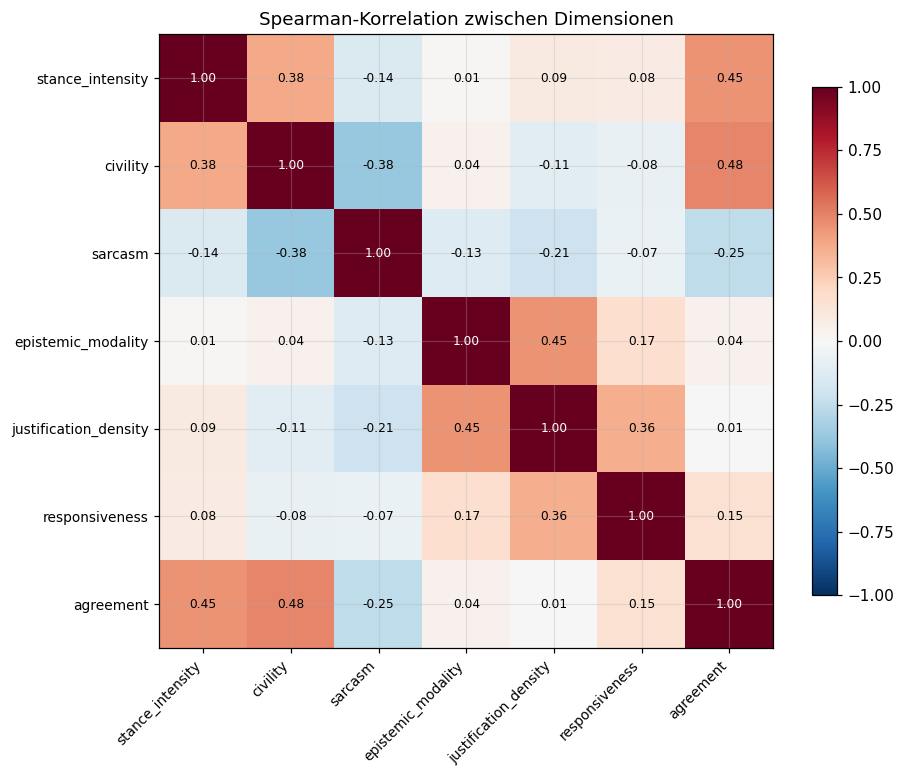

,stance_intensity,civility,sarcasm,epistemic_modality,justification_density,responsiveness,agreement
stance_intensity,1.00,0.38,-0.14,0.01,0.09,0.08,0.45
civility,0.38,1.00,-0.38,0.04,-0.11,-0.08,0.48
sarcasm,-0.14,-0.38,1.00,-0.13,-0.21,-0.07,-0.25
epistemic_modality,0.01,0.04,-0.13,1.00,0.45,0.17,0.04
justification_density,0.09,-0.11,-0.21,0.45,1.00,0.36,0.01
responsiveness,0.08,-0.08,-0.07,0.17,0.36,1.00,0.15
agreement,0.45,0.48,-0.25,0.04,0.01,0.15,1.00


In [14]:
# Spearman-Korrelationsmatrix über die Dimensionswerte
corr_df = dfc[ALL_DIMS].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9,7.5))
im = ax.imshow(corr_df.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(ALL_DIMS))); ax.set_xticklabels(ALL_DIMS, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(ALL_DIMS))); ax.set_yticklabels(ALL_DIMS, fontsize=9)
for i in range(len(ALL_DIMS)):
    for j in range(len(ALL_DIMS)):
        v = corr_df.values[i,j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color="white" if abs(v)>0.5 else "black", fontsize=8)
ax.set_title("Spearman-Korrelation zwischen Dimensionen")
fig.colorbar(im, ax=ax, shrink=0.8)
save(fig, "07a_korrelationsmatrix"); plt.show()
display(corr_df.round(2))

In [15]:
# Die stärksten Korrelationen (Betrag) als Liste
pairs = []
for i in range(len(ALL_DIMS)):
    for j in range(i+1, len(ALL_DIMS)):
        v = corr_df.values[i,j]
        if not np.isnan(v):
            pairs.append((abs(v), ALL_DIMS[i], ALL_DIMS[j], v))
pairs.sort(reverse=True)
print("Stärkste Zusammenhänge (Spearman):")
for a, x, y, v in pairs[:8]:
    print(f"  {x:22} <-> {y:22}  rho={v:+.3f}")

Stärkste Zusammenhänge (Spearman):
  civility               <-> agreement               rho=+0.485
  epistemic_modality     <-> justification_density   rho=+0.450
  stance_intensity       <-> agreement               rho=+0.447
  civility               <-> sarcasm                 rho=-0.376
  stance_intensity       <-> civility                rho=+0.376
  justification_density  <-> responsiveness          rho=+0.362
  sarcasm                <-> agreement               rho=-0.252
  sarcasm                <-> justification_density   rho=-0.207


  gespeichert: plots/07b_top_paare.png


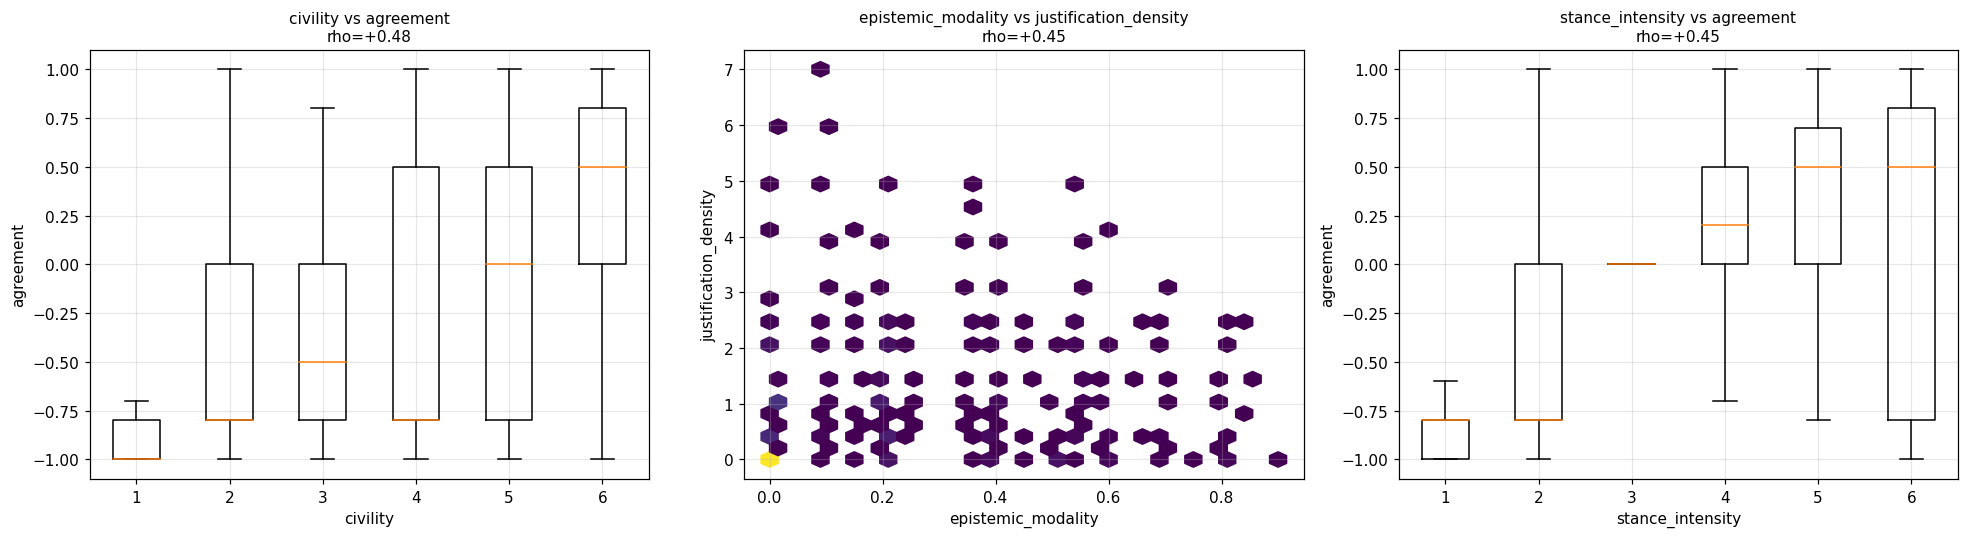

In [16]:
# Gezielte Paar-Plots für die drei stärksten Paare, je nach Typ passend
def plot_pair(ax, xcol, ycol):
    sub = dfc[[xcol, ycol]].dropna()
    xo = xcol in ORDINAL or xcol in BINARY
    yo = ycol in ORDINAL or ycol in BINARY
    if xo and yo:
        ct = pd.crosstab(sub[ycol], sub[xcol])
        im = ax.imshow(ct.values, aspect="auto", cmap="viridis", origin="lower")
        ax.set_xticks(range(len(ct.columns))); ax.set_xticklabels(ct.columns)
        ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index)
    elif (not xo) and (not yo):
        hb = ax.hexbin(sub[xcol], sub[ycol], gridsize=30, cmap="viridis", mincnt=1)
    else:
        # gemischt: ordinal auf x, kontinuierlich auf y -> Boxplot
        ocol, ccol = (xcol, ycol) if xo else (ycol, xcol)
        levels = sorted(sub[ocol].dropna().unique())
        data = [sub[sub[ocol]==lv][ccol].values for lv in levels]
        ax.boxplot(data, labels=[str(int(l)) for l in levels], showfliers=False)
        ax.set_xlabel(ocol); ax.set_ylabel(ccol)
        return
    ax.set_xlabel(xcol); ax.set_ylabel(ycol)

top = pairs[:3] if len(pairs)>=3 else pairs
fig, axes = plt.subplots(1, len(top), figsize=(6*len(top), 5))
if len(top)==1: axes=[axes]
for ax,(a,x,y,v) in zip(axes, top):
    plot_pair(ax, x, y)
    ax.set_title(f"{x} vs {y}\nrho={v:+.2f}", fontsize=10)
plt.tight_layout()
save(fig, "07b_top_paare"); plt.show()

  gespeichert: plots/07c_scatter_matrix.png


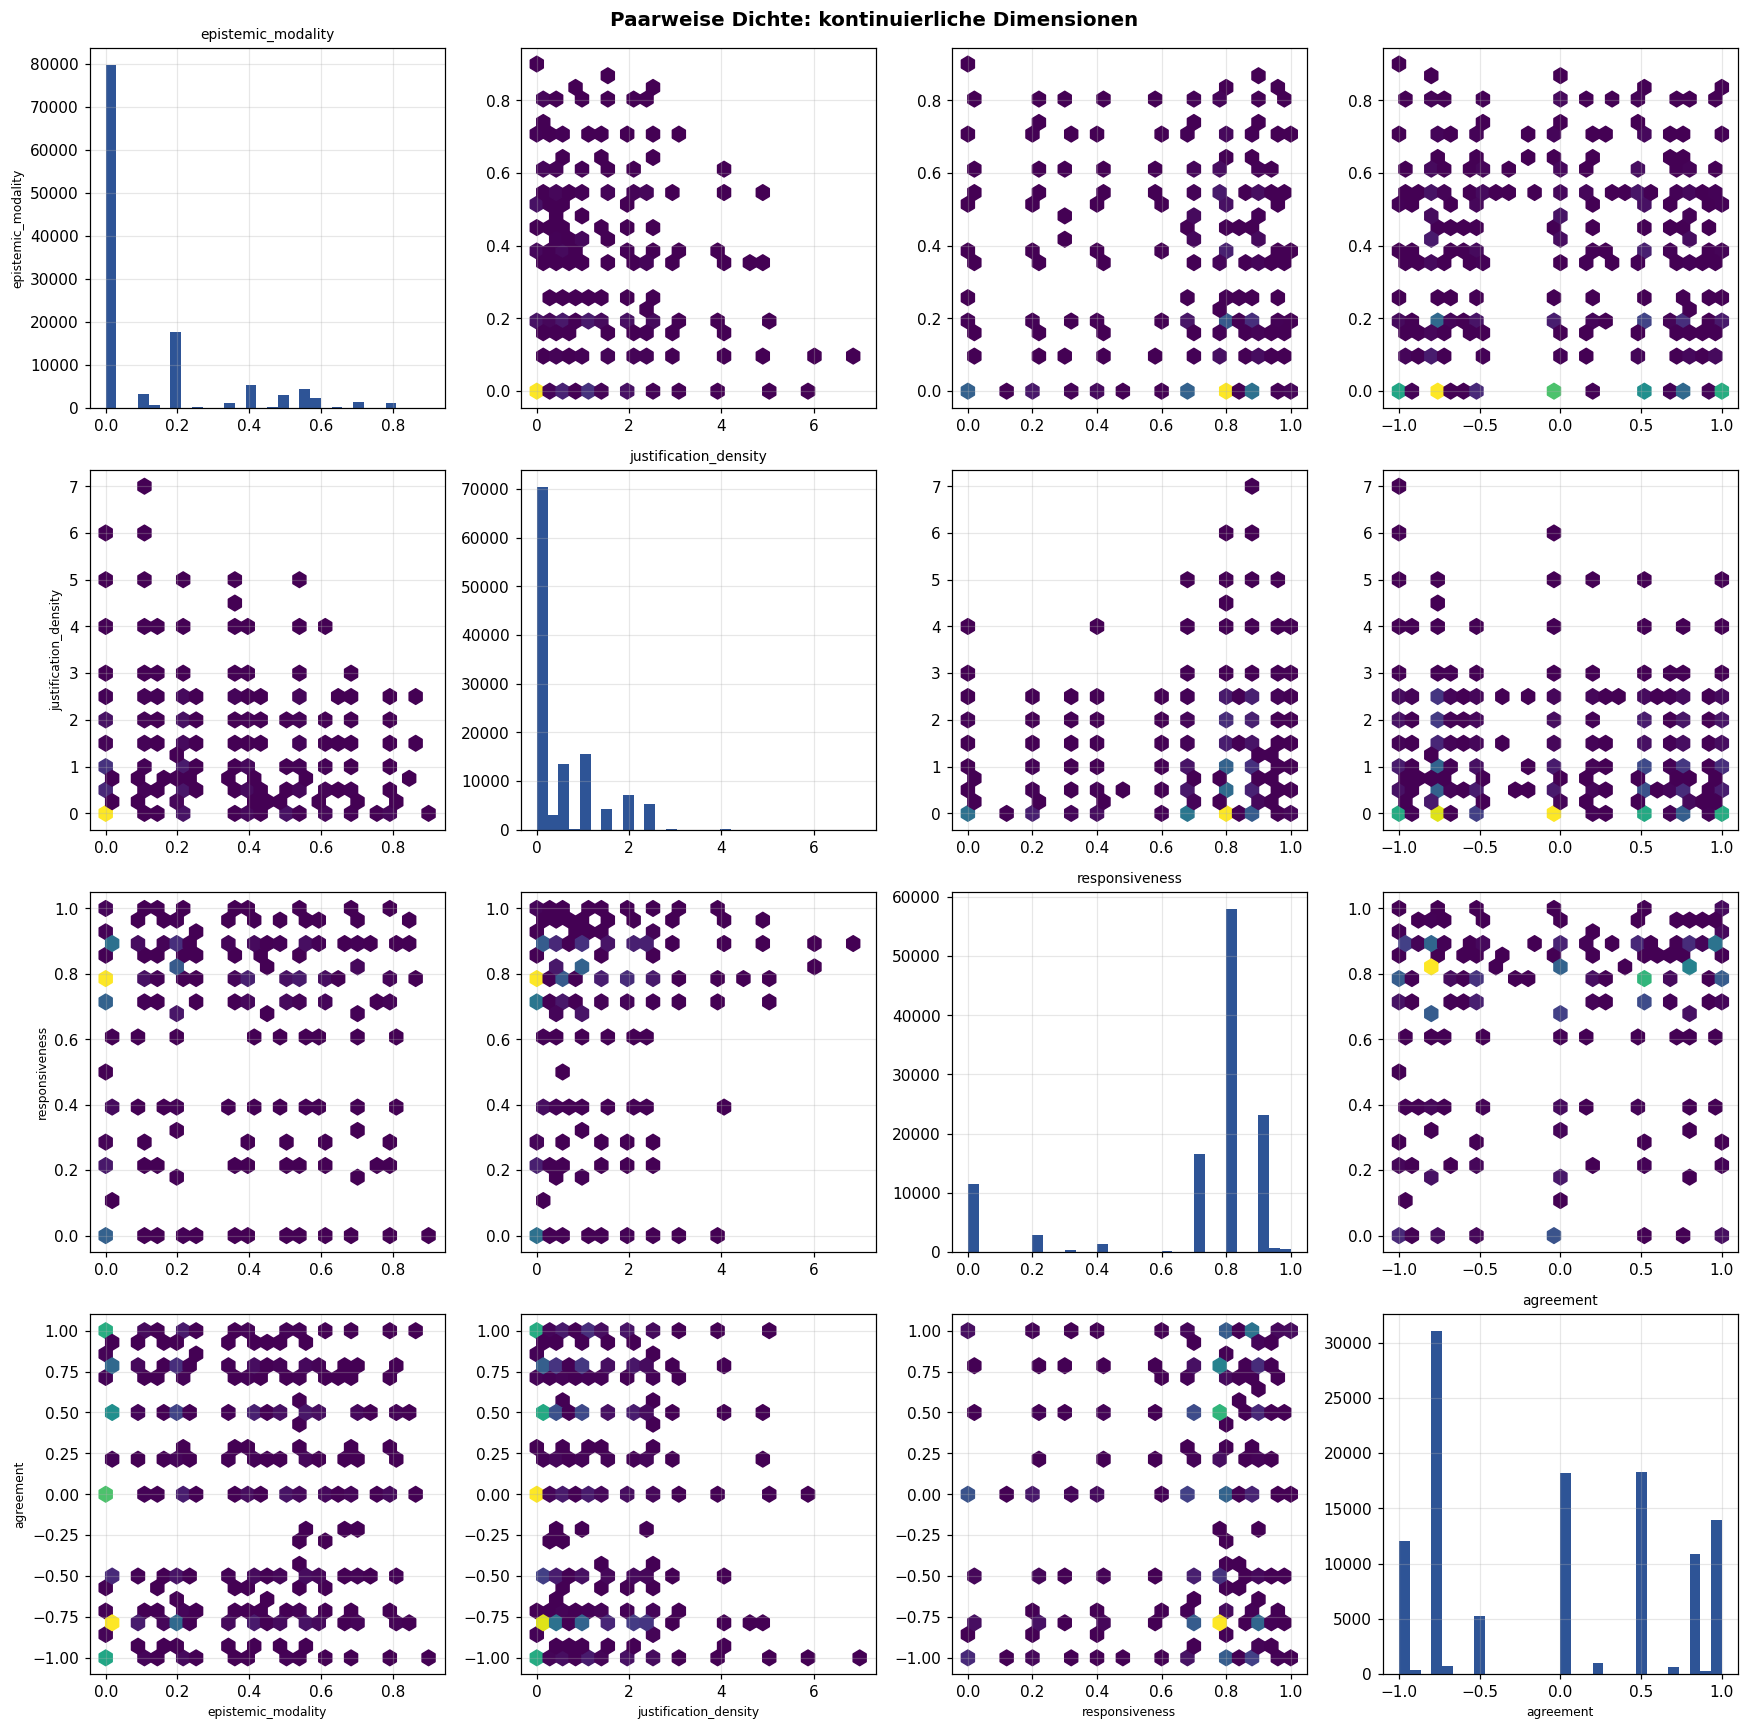

In [17]:
# Vollständige Scatter/Density-Matrix der 4 kontinuierlichen Dimensionen
cont = [c for c in CONT if dfc[c].notna().sum() > 100]
n = len(cont)
fig, axes = plt.subplots(n, n, figsize=(4*n, 4*n))
for i, yc in enumerate(cont):
    for j, xc in enumerate(cont):
        ax = axes[i, j]
        if i == j:
            ax.hist(dfc[xc].dropna(), bins=30, color="#2E5496")
            ax.set_title(xc, fontsize=9)
        else:
            sub = dfc[[xc, yc]].dropna()
            if len(sub) > 0:
                ax.hexbin(sub[xc], sub[yc], gridsize=25, cmap="viridis", mincnt=1)
        if i == n-1: ax.set_xlabel(xc, fontsize=8)
        if j == 0:   ax.set_ylabel(yc, fontsize=8)
fig.suptitle("Paarweise Dichte: kontinuierliche Dimensionen", fontsize=13, fontweight="bold")
plt.tight_layout()
save(fig, "07c_scatter_matrix"); plt.show()

## 8. Konfidenz vs. Kommentarlänge

Nutzt das Modell bei sehr kurzen Kommentaren tatsächlich niedrigere Konfidenz?
`n_tokens` liegt pro Kommentar vor.

  gespeichert: plots/08_konfidenz_vs_laenge.png


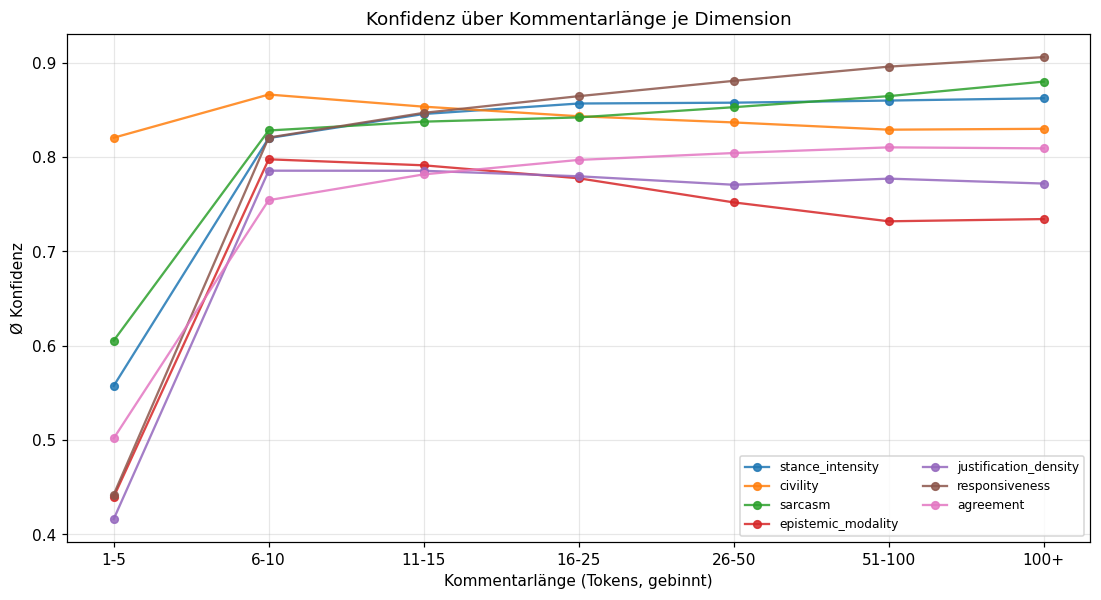

In [18]:
d2 = dfc.dropna(subset=["n_tokens"]).copy()
d2["tok_bin"] = pd.cut(d2["n_tokens"].clip(upper=200),
                       bins=[0,5,10,15,25,50,100,200],
                       labels=["1-5","6-10","11-15","16-25","26-50","51-100","100+"])
fig, ax = plt.subplots(figsize=(12,6))
for t in ALL_DIMS:
    g = d2.groupby("tok_bin", observed=True)[f"{t}__conf"].mean()
    ax.plot(g.index.astype(str), g.values, marker="o", markersize=5, label=t, alpha=0.85)
ax.set_xlabel("Kommentarlänge (Tokens, gebinnt)")
ax.set_ylabel("Ø Konfidenz")
ax.set_title("Konfidenz über Kommentarlänge je Dimension")
ax.legend(fontsize=8, ncol=2)
save(fig, "08_konfidenz_vs_laenge"); plt.show()

## 9. Aufschlüsselung nach Subreddit

  gespeichert: plots/09_subreddit_heatmap.png


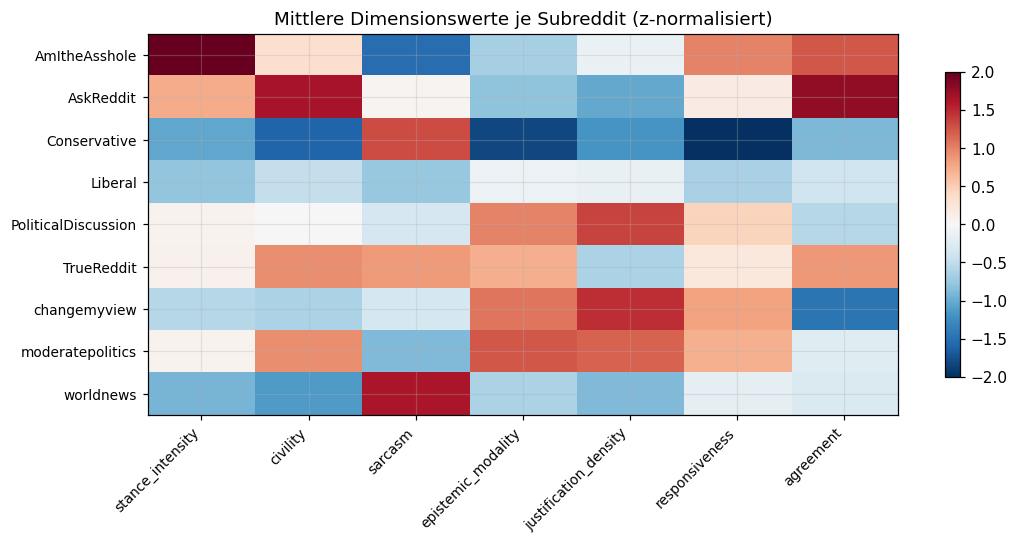

,stance_intensity,civility,sarcasm,epistemic_modality,justification_density,responsiveness,agreement
subreddit,,,,,,,
AmItheAsshole,4.64,4.43,0.17,0.10,0.59,0.80,0.10
AskReddit,4.21,4.75,0.26,0.10,0.37,0.72,0.18
Conservative,3.74,3.96,0.34,0.05,0.34,0.48,-0.20
Liberal,3.81,4.23,0.21,0.13,0.58,0.65,-0.13
PoliticalDiscussion,4.04,4.35,0.24,0.17,0.94,0.75,-0.16
TrueReddit,4.04,4.58,0.31,0.16,0.47,0.73,0.05
changemyview,3.87,4.20,0.24,0.18,0.97,0.78,-0.29
moderatepolitics,4.04,4.58,0.21,0.18,0.90,0.77,-0.11
worldnews,3.77,4.07,0.36,0.10,0.41,0.69,-0.12


In [19]:
if dfc["subreddit"].notna().any():
    # Mittlere Werte je Subreddit je Dimension als Heatmap
    means = dfc.groupby("subreddit")[ALL_DIMS].mean()
    # z-normalisieren je Spalte für Vergleichbarkeit
    z = (means - means.mean()) / means.std(ddof=0)
    fig, ax = plt.subplots(figsize=(11, max(3, len(means)*0.5)))
    im = ax.imshow(z.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_xticks(range(len(ALL_DIMS))); ax.set_xticklabels(ALL_DIMS, rotation=45, ha="right", fontsize=9)
    ax.set_yticks(range(len(means.index))); ax.set_yticklabels(means.index, fontsize=9)
    ax.set_title("Mittlere Dimensionswerte je Subreddit (z-normalisiert)")
    fig.colorbar(im, ax=ax, shrink=0.8)
    save(fig, "09_subreddit_heatmap"); plt.show()
    display(means.round(2))

---
*Alle Grafiken liegen zusätzlich als PNG in `./plots/`.*

Für ein belastbares Qualitätsurteil (nicht nur Verteilung/Zusammenhang, sondern
Korrektheit) bleibt der nächste Schritt ein handgelabeltes Gold-Set, gegen das
sich die Modell-Labels und die Konfidenz-Kalibrierung messen lassen.
